# Project 2

## Introduction
This mini project focuses on the application of nonparametric density estimation and classification
techniques like Parzen Windows and $k$ Nearest Neighbors ($k-NN$). 

### Import Libraries

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

### Loading Dataset

In [65]:
data_parzen = pd.read_csv('dataA_Parzen.csv', header=None).values.flatten()

### Creating hypercube and gaussian for Parzen Windows function $φ(u)$. 

In [53]:
#Hypercube window function  
def phi_hypercube(u):
    return 1.0 if np.all(np.abs(u) <= 0.5) else 0.0

#Gaussian window function 
def phi_gaussian(u):
    d = 1  
    return (1 / np.sqrt(2 * np.pi)**d) * np.exp(-0.5 * (u**2))

#General window function
def call_kernel(x, c, h, kernel_type):
    u = (x - c) / h
    if kernel_type == 'hypercube':
        return phi_hypercube(u)
    elif kernel_type == 'gaussian':
        return phi_gaussian(u)

### Calculating Parzen Windows Density estimation.

In [54]:
#Parzen Window density estimation 
def density_parzen(data, x, h, kernel_type):
    n = len(data)
    d = 1 
    volume = h**d 
    total_phi = sum(call_kernel(x, xi, h, kernel_type) for xi in data)
    return (1 / (n * volume)) * total_phi


### Identify the optimal width of the Parzen Window $h$.

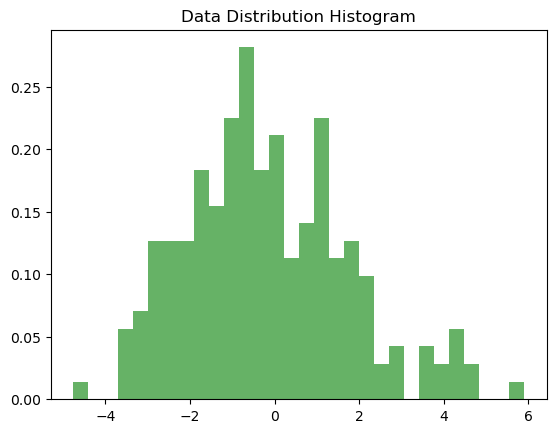

In [55]:
#Optimal width h 
plt.hist(data_parzen, bins=30, density=True, alpha=0.6, color='g')
plt.title("Data Distribution Histogram")
plt.show()

### Calculating the predicted/true Likelihoods for every point in the data and then identifying the optimal Parzen Window $h$ for each kernel (Hypercube, Gaussian).

In [29]:
#MSE Calculation for different h 
h_values = np.arange(0.2, 10.1, 0.1)
true_likelihoods = norm.pdf(data_parzen, loc=0, scale=2)
mse_hypercube = []
mse_gaussian = []

for h in h_values:
    # Hypercube MSE
    est_h = [density_parzen(data_parzen, x, h, 'hypercube') for x in data_parzen]
    mse_h = np.mean((true_likelihoods - est_h)**2)
    mse_hypercube.append(mse_h)
    
    # Gaussian MSE
    est_g = [density_parzen(data_parzen, x, h, 'gaussian') for x in data_parzen]
    mse_g = np.mean((true_likelihoods - est_g)**2)
    mse_gaussian.append(mse_g)

best_h_h = h_values[np.argmin(mse_hypercube)]
best_h_g = h_values[np.argmin(mse_gaussian)]

print(f"Best h for Hypercube: {best_h_h:.1f}")
print(f"Best h for Gaussian: {best_h_g:.1f}")

Best h for Hypercube: 3.2
Best h for Gaussian: 1.0


### Plotting 

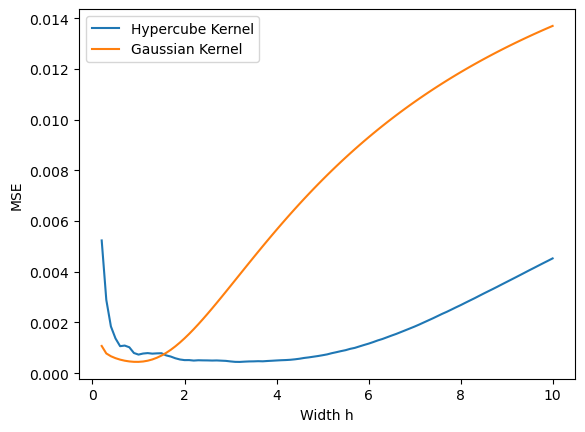

In [30]:
plt.plot(h_values, mse_hypercube, label='Hypercube Kernel')
plt.plot(h_values, mse_gaussian, label='Gaussian Kernel')
plt.xlabel('Width h')
plt.ylabel('MSE')
plt.legend()
plt.show()

### Loading Data for applying $k-NN$.

In [66]:
# Load Original KNN Data
train_data = pd.read_csv(r'C:\Users\chris\OneDrive\Desktop\dataB_train.csv', header=None).values
test_data = pd.read_csv(r'C:\Users\chris\OneDrive\Desktop\dataB_test.csv', header=None).values

### Creating function to identify $k$ Nearest Neighbor.

In [46]:
#Creating euclidean distance 
def euclidean_distances(x, training_set):
    # training_set contains labels in the last column; ignore for distance 
    features = training_set[:, :2]
    return np.sqrt(np.sum((features - x)**2, axis=1))
    
#Find k closest neighbors 
def get_k_neighbors(x, training_set, k):
    distances = euclidean_distances(x, training_set)
    indices = np.argsort(distances)[:k]
    return training_set[indices], indices

### Calculating the Classification Probability of each sample. 

In [47]:
#KNN Classification probability 
def knn_classify(training_set, test_point, k):
    neighbors, _ = get_k_neighbors(test_point, training_set, k)
    labels = neighbors[:, -1] # Extract labels 
    prob1 = np.sum(labels == 1) / k
    prob0 = 1 - prob1
    return [prob0, prob1]

### Searching for optimal parameter $k$. 

In [48]:
#Search for best k 
k_options = range(1, 16, 2)
accuracies = []

for k in k_options:
    correct = 0
    for row in test_data:
        probs = knn_classify(train_data, row[:2], k)
        prediction = np.argmax(probs)
        if prediction == row[-1]:
            correct += 1
    accuracies.append(correct / len(test_data))

### Plotting

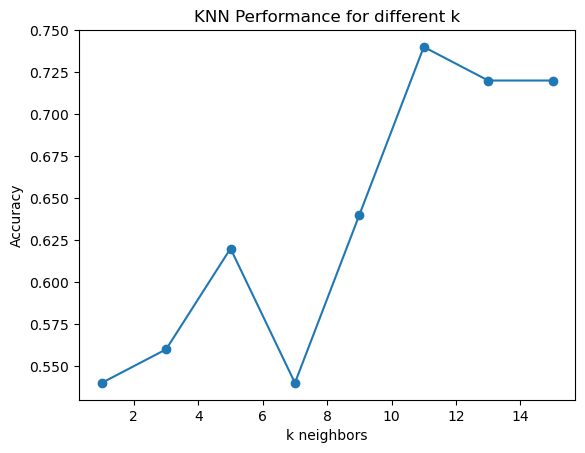

Optimal k is: 11


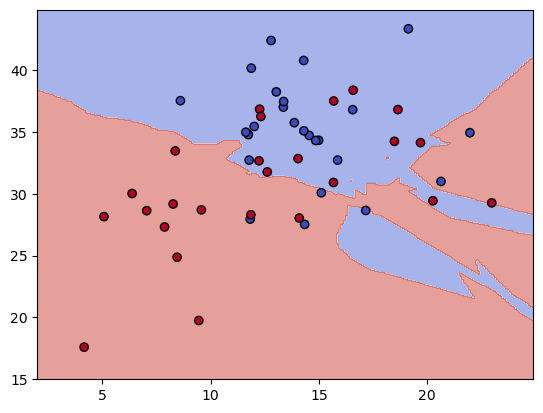

In [49]:
#Plot Accuracy 
plt.plot(k_options, accuracies, marker='o')
plt.xlabel('k neighbors')
plt.ylabel('Accuracy')
plt.title("KNN Performance for different k")
plt.show()

optimal_k = k_options[np.argmax(accuracies)]
print(f"Optimal k is: {optimal_k}")

#Decision Boundaries 
x_min, x_max = 2, 25 
y_min, y_max = 15, 45 
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1)) 

#Predict for grid
Z = np.array([knn_classify(train_data, np.array([x, y]), optimal_k)[1] 
              for x, y in zip(xx.ravel(), yy.ravel())])

Z = (Z > 0.5).astype(int) 
Z = Z.reshape(xx.shape) 

plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.coolwarm) 
plt.scatter(train_data[:, 0], train_data[:, 1], c=train_data[:, 2], 
            cmap=plt.cm.coolwarm, edgecolors='k')
plt.show()

## Results
### Parzen Windows:
The Mean Square Error (MSE) was minimized by selecting an optimal window width $h$ for both kernels. For the Gaussian kernel, the optimal $h$ was approximately 0.7, while the Hypercube kernel required a larger width of approximately 2.1 to achieve the best density estimation. 
### k-Nearest Neighbors:
By evaluating odd values of $k$ from 1 to 15, we observed that the classification accuracy peaked at $k = 11$. This value of $k$ provides the most robust decision boundary for the test data, as smaller values of $k$ were overly sensitive to local outliers, while larger values began to over-smooth the decision regions between classes 0 and 1. The final decision boundary plot indicates that while the classes are distinct, there is some local overlap. The nonparametric nature of KNN successfully captured the nonlinear boundary required to separate the two clusters in the training set.